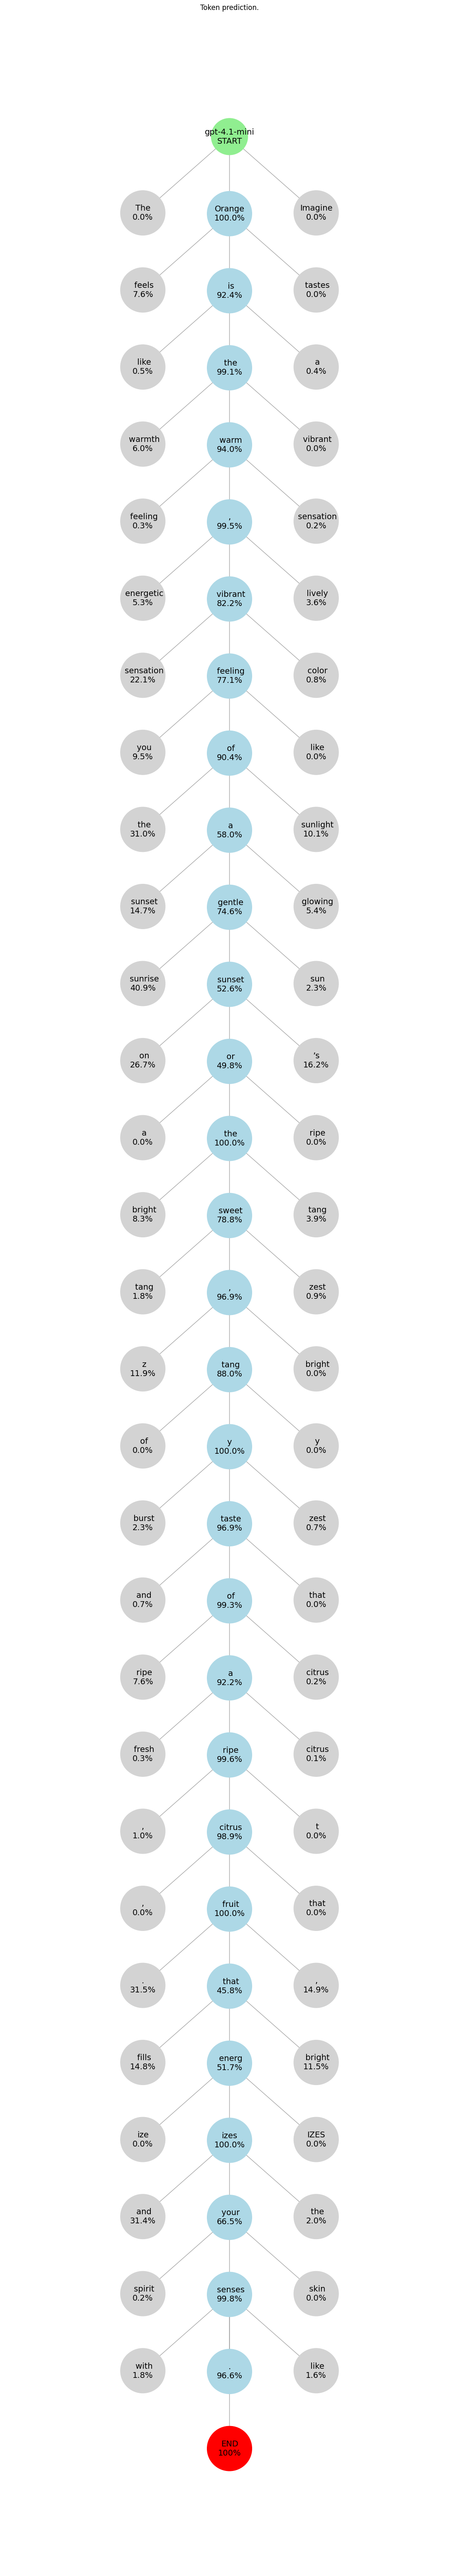

In [1]:
from visualizer import TokenPredictor, create_token_graph, visualize_predictions

message = "In one sentence, describe the color orange to someone who has never been able to see"
model_name = "gpt-4.1-mini"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
G = create_token_graph(model_name, predictions)
plt = visualize_predictions(G)
plt.show()

## Meeting Minutes Assistant

Create meeting minutes from an Audio file

I downloaded some Denver City Council meeting minutes and selected a portion of the meeting for us to transcribe. You can download it here:
https://drive.google.com/file/d/1N_kpSojRR5RYzupz6nqM8hMSoEF_R7pU/view?usp=sharing

If you'd rather work with the original data, the HuggingFace dataset is here and the audio can be downloaded here.

The goal of this product is to use the Audio to generate meeting minutes, including actions.

For this project, you can either use the Denver meeting minutes, or you can record something of your own!

In [ ]:
!pip install -q --upgrade bitsandbytes accelerate transformers==4.57.6

In [ ]:
import os
import requests
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from google.colab import drive, userdata
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch


In [ ]:
QWEN = 'Qwen/Qwen3.6-35B-A3B'
LLAMA = "meta-llama/Llama-3.1-8B-Instruct"

In [ ]:
# New capability - connect this Colab to your Google Drive
# See immediately below this for instructions to obtain denver_extract.mp3
# Place the file on your drive in a folder called llms, and call it denver_extract.mp3

drive.mount("/content/drive")
audio_filename = "/content/drive/MyDrive//denver_extract.mp3"

In [ ]:
# sign in to huggingface

hf_token = userdata("HF_TOKEN")
login(hf_token, add_to_git_credential=True)

#open file

audio_file = open(audio_filename, "rb")

## Step 1: Transcription

In [ ]:
# using huggingface/opensource
from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-medium.en",
    dtype=torch.float16,
    device='cuda',
    return_timestamps=True
)

result = pipe(audio_filename)
transcription = result["text"]
print(transcription)

In [ ]:
#using openai
AUDIO_MODEL = "gpt-4o-mini-transcribe"

openai_api_key = userdata.get('OPENAI_API_KEY')
openai = OpenAI(api_key=openai_api_key)

transcription = openai.audio.transcriptions.create(model=AUDIO_MODEL, file=audio_file. response_format='text')
print(transcription)


In [ ]:
display(Markdown(open_source_transcription))
print("\n\n")
display(Markdown(transcription))

## Step 2: Analyse & Report

In [ ]:
system_message = """
You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.
"""

user_prompt = f"""
Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
{transcription}
"""

messages = [
    {"role":"system", "content": system_message},
    {"role":"user", "user_prompt": user_prompt}
]

In [ ]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(LLAMA, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda") #tensors in pytorch styles
# apply template to turn messages into a sequence, turn into pytorch and put on cuda
streamer = TextStreamer(tokenizer)
model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quant_config, trust_remote_code=True)
outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)


In [ ]:
response = tokenizer.decode(outputs[0])

In [ ]:
display(Markdown(response))